**Imports:**

In [47]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import kagglehub
import json
from collections import defaultdict
from PIL import ImageDraw
from google.colab import files

print("Libraries Imported Successfully.")

Libraries Imported Successfully.


**Configuration:**

In [38]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 384
BATCH_SIZE = 8 if torch.cuda.is_available() else 4

NUM_EPOCHS = 20

LEARNING_RATE = 3e-4
EARLY_STOPPING_PATIENCE = 8
NUM_WORKERS = 2

print(f"Device: {DEVICE}")
print(f"Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {NUM_EPOCHS}")

Device: cuda
Image Size: 384x384
Batch Size: 8
Epochs: 20


**Install KaggleHub:**

In [3]:
!pip install -q kagglehub

print("KaggleHub Installed Successfully.")

KaggleHub Installed Successfully.


**Download FracAtlas:**

In [4]:
dataset_path = kagglehub.dataset_download(
    "mahmudulhasantasin/fracatlas-original-dataset"
)

print("Dataset Downloaded Successfully.")
print(f"Dataset Path: {dataset_path}")

100%|██████████| 323M/323M [00:02<00:00, 141MB/s]

Extracting files...


Dataset Downloaded Successfully.
Dataset Path: /root/.cache/kagglehub/datasets/mahmudulhasantasin/fracatlas-original-dataset/versions/1


**Explore Dataset Directory:**

In [5]:
for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    sub_indent = "    " * (level + 1)

    for file in files[:10]:
        print(f"{sub_indent}{file}")

    if level >= 2:
        dirs[:] = []

1/
    FracAtlas/
        dataset.csv
        Annotations/
        Utilities/
            coco2yolo.ipynb
            yolo2voc.ipynb
        images/


**Count Files:**

In [6]:
file_count = 0
for root, _, files in os.walk(dataset_path):
    file_count += len(files)

print(f"Total Files: {file_count}")

Total Files: 12258


**Inspect Dataset CSV:**

In [7]:
csv_path = os.path.join(dataset_path, "FracAtlas", "dataset.csv")
df = pd.read_csv(csv_path)

print(f"Dataset Shape: {df.shape}")
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

Dataset Shape: (4083, 13)

Column Names:
['image_id', 'hand', 'leg', 'hip', 'shoulder', 'mixed', 'hardware', 'multiscan', 'fractured', 'fracture_count', 'frontal', 'lateral', 'oblique']

First 5 Rows:


,image_id,hand,leg,hip,shoulder,mixed,hardware,multiscan,fractured,fracture_count,frontal,lateral,oblique
0,IMG0000000.jpg,0,1,0,0,0,0,1,0,0,1,1,0
1,IMG0000001.jpg,0,1,0,0,0,0,1,0,0,1,1,0
2,IMG0000002.jpg,0,1,0,0,0,0,1,0,0,1,1,0
3,IMG0000003.jpg,0,1,0,0,0,0,1,0,0,0,1,1
4,IMG0000004.jpg,0,1,0,0,0,0,1,0,0,0,1,1


**Dataset Information:**

In [8]:
print("Dataset Information:")
print()

df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4083 entries, 0 to 4082
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   image_id        4083 non-null   object
 1   hand            4083 non-null   int64 
 2   leg             4083 non-null   int64 
 3   hip             4083 non-null   int64 
 4   shoulder        4083 non-null   int64 
 5   mixed           4083 non-null   int64 
 6   hardware        4083 non-null   int64 
 7   multiscan       4083 non-null   int64 
 8   fractured       4083 non-null   int64 
 9   fracture_count  4083 non-null   int64 
 10  frontal         4083 non-null   int64 
 11  lateral         4083 non-null   int64 
 12  oblique         4083 non-null   int64 
dtypes: int64(12), object(1)
memory usage: 414.8+ KB


**Missing Values:**

In [9]:
missing_values = df.isnull().sum()
print("Missing Values Per Column:")

display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No Missing Values Found.")

Missing Values Per Column:


,0


No Missing Values Found.


**Unique Values:**

In [10]:
for column in df.columns:
  print(f"\nColumn: {column}")
  print(f"Unique Values: {df[column].nunique()}")

  if df[column].nunique() <= 20:
    print(df[column].value_counts(dropna=False))


Column: image_id
Unique Values: 4083

Column: hand
Unique Values: 2
hand
0    2545
1    1538
Name: count, dtype: int64

Column: leg
Unique Values: 2
leg
1    2273
0    1810
Name: count, dtype: int64

Column: hip
Unique Values: 2
hip
0    3745
1     338
Name: count, dtype: int64

Column: shoulder
Unique Values: 2
shoulder
0    3734
1     349
Name: count, dtype: int64

Column: mixed
Unique Values: 2
mixed
0    3685
1     398
Name: count, dtype: int64

Column: hardware
Unique Values: 2
hardware
0    3984
1      99
Name: count, dtype: int64

Column: multiscan
Unique Values: 2
multiscan
0    3687
1     396
Name: count, dtype: int64

Column: fractured
Unique Values: 2
fractured
0    3366
1     717
Name: count, dtype: int64

Column: fracture_count
Unique Values: 6
fracture_count
0    3366
1     546
2     146
3      17
4       7
5       1
Name: count, dtype: int64

Column: frontal
Unique Values: 2
frontal
1    2503
0    1580
Name: count, dtype: int64

Column: lateral
Unique Values: 2
lateral


**Image Directory Analysis:**

In [11]:
from numpy._core.defchararray import lower
image_path = os.path.join(dataset_path, "FracAtlas", "images")

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

image_files = []

for root, _, files in os.walk(image_path):
    for file in files:
      if os.path.splitext(file)[1].lower() in image_extensions:
        image_files.append(os.path.join(root, file))

print(f"Total Image Files: {len(image_files)}")

Total Image Files: 4083


**Annotation Directory Analysis:**

In [12]:
annotations_path = os.path.join(dataset_path, "FracAtlas", "Annotations")

annotation_files = []

for root, _, files in os.walk(annotations_path):
    for file in files:
        annotation_files.append(os.path.join(root, file))

print(f"Total Annotation Files: {len(annotation_files)}")
print("\nAnnotation File Types:")

annotation_extensions = {}

for file in annotation_files:
    extension = "No Extension"

annotation_extensions[extension] = annotation_extensions.get(extension, 0) + 1

for extension, count in annotation_extensions.items():
    print(f"{extension}: {count}")

Total Annotation Files: 8169

Annotation File Types:
No Extension: 1


**Explore Annotation Structure:**

In [13]:
for root, dir, file in os.walk(annotations_path):
  level = root.replace(annotations_path, "").count(os.sep)
  indent = "    " * level

  print(f"{indent}{os.path.basename(root)}/")

  sub_indent = "    " * (level + 1)

  for file in files[:15]:
    print(f"{sub_indent}{file}")

  if level >= 3:
    dirs[:] = []

Annotations/
    IMG0002996.txt
    IMG0002466.txt
    IMG0000385.txt
    IMG0002473.txt
    IMG0000569.txt
    IMG0000567.txt
    IMG0001869.txt
    IMG0002995.txt
    IMG0003808.txt
    IMG0001029.txt
    IMG0002355.txt
    IMG0000044.txt
    IMG0002731.txt
    IMG0003797.txt
    IMG0002431.txt
    PASCAL VOC/
        IMG0002996.txt
        IMG0002466.txt
        IMG0000385.txt
        IMG0002473.txt
        IMG0000569.txt
        IMG0000567.txt
        IMG0001869.txt
        IMG0002995.txt
        IMG0003808.txt
        IMG0001029.txt
        IMG0002355.txt
        IMG0000044.txt
        IMG0002731.txt
        IMG0003797.txt
        IMG0002431.txt
    COCO JSON/
        IMG0002996.txt
        IMG0002466.txt
        IMG0000385.txt
        IMG0002473.txt
        IMG0000569.txt
        IMG0000567.txt
        IMG0001869.txt
        IMG0002995.txt
        IMG0003808.txt
        IMG0001029.txt
        IMG0002355.txt
        IMG0000044.txt
        IMG0002731.txt
        IMG0003797.txt
    

**Inspect Annotation File:**

In [14]:
sample_annotation = None

for root, _, files in os.walk(annotations_path):
    for file in files:
        if file.lower().endswith(".json"):
            sample_annotation = os.path.join(root, file)
            break

    if sample_annotation:
        break

print(f"Sample Annotation: {sample_annotation}")

if sample_annotation:
    with open(sample_annotation, "r", encoding="utf-8", errors="replace") as f:
        content = f.read()

    print("\nAnnotation Content:")
    print(content[:3000])

Sample Annotation: /root/.cache/kagglehub/datasets/mahmudulhasantasin/fracatlas-original-dataset/versions/1/FracAtlas/Annotations/COCO JSON/COCO_fracture_masks.json

Annotation Content:
{
  "info": { "description": "my-project-name" },
  "images": [
    { "id": 1, "width": 2304, "height": 2880, "file_name": "IMG0000019.jpg" },
    { "id": 2, "width": 2880, "height": 2304, "file_name": "IMG0000025.jpg" },
    { "id": 3, "width": 2304, "height": 2880, "file_name": "IMG0000044.jpg" },
    { "id": 4, "width": 2304, "height": 2880, "file_name": "IMG0000057.jpg" },
    { "id": 5, "width": 2304, "height": 2880, "file_name": "IMG0000058.jpg" },
    { "id": 6, "width": 2304, "height": 2880, "file_name": "IMG0000059.jpg" },
    { "id": 7, "width": 2304, "height": 2880, "file_name": "IMG0000092.jpg" },
    { "id": 8, "width": 2304, "height": 2880, "file_name": "IMG0000100.jpg" },
    { "id": 9, "width": 2304, "height": 2880, "file_name": "IMG0000142.jpg" },
    { "id": 10, "width": 2304, "height"

**Inspect Image Names:**

In [15]:
print("First 20 Image Files:")

for image_file in image_files[:20]:
    print(os.path.basename(image_file))

First 20 Image Files:
IMG0002376.jpg
IMG0002399.jpg
IMG0002498.jpg
IMG0002351.jpg
IMG0002750.jpg
IMG0002324.jpg
IMG0001948.jpg
IMG0002604.jpg
IMG0000600.jpg
IMG0003382.jpg
IMG0002350.jpg
IMG0002548.jpg
IMG0002421.jpg
IMG0002579.jpg
IMG0002646.jpg
IMG0002585.jpg
IMG0004232.jpg
IMG0002415.jpg
IMG0001410.jpg
IMG0002379.jpg


**Load COCO Annotation:**

In [16]:
coco_path = os.path.join(annotations_path, "COCO JSON", "COCO_fracture_masks.json")

with open(coco_path, "r", encoding="utf-8") as f:
  coco_data = json.load(f)

print("COCO Annotation Loaded Successfully.")
print("\nTop-Level Keys:")
print(list(coco_data.keys()))

COCO Annotation Loaded Successfully.

Top-Level Keys:
['info', 'images', 'annotations', 'categories']


**Analyze COCO Annotation:**

In [17]:
for key, value in coco_data.items():
  if isinstance(value, list):
    print(f"{key}: {len(value)}")
  elif isinstance(value, dict):
    print(f"{key}: Dictionary")
  else:
    print(f"{key}: {type(value).__name__}")

info: Dictionary
images: 717
annotations: 922
categories: 1


**Inspect Annotation Categories:**

In [18]:
categories = coco_data.get("categories", [])

print(f"Number Of Categories: {len(categories)}")

for category in categories:
  print(category)

Number Of Categories: 1
{'id': 0, 'name': 'fractured'}


**Inspect Sample Annotations:**

In [19]:
annotations = coco_data.get("annotations", [])
print(f"Number Of Annotations: {len(annotations)}")

if annotations:
  print("\nSample Annotation:")
  print(json.dumps(annotations[0], indent=2)[:3000])

Number Of Annotations: 922

Sample Annotation:
{
  "id": 0,
  "iscrowd": 0,
  "image_id": 1,
  "category_id": 0,
  "segmentation": [
    [
      1266.0594059405942,
      1045.5445544554457,
      1339.7227722772277,
      1021.782178217822,
      1401.5049504950496,
      1052.673267326733,
      1489.4257425742576,
      1076.4356435643565,
      1515.5643564356437,
      1021.782178217822,
      1449.0297029702972,
      943.3663366336635,
      1308.8316831683169,
      929.1089108910893,
      1242.2970297029703,
      986.1386138613863
    ]
  ],
  "bbox": [
    1242.2970297029703,
    929.1089108910893,
    273.2673267326734,
    147.3267326732672
  ],
  "area": 25033.78100186259
}


**Compare Images And Annotations:**

In [20]:
coco_images = coco_data.get("images", [])
coco_annotations = coco_data.get("annotations", [])

print(f"COCO Images: {len(coco_images)}")
print(f"COCO Annotations: {len(coco_annotations)}")

annotated_image_ids = {
    annotation["image_id"]
    for annotation in coco_annotations
    if "image_id" in annotation
}

print(f"Images With Annotations: {len(annotated_image_ids)}")

COCO Images: 717
COCO Annotations: 922
Images With Annotations: 717


**Inspect COCO Categories:**

In [21]:
print("COCO Categories")
print("=" * 50)

for category in coco_data["categories"]:
  print(f"ID            : {category['id']}")
  print(f"Name          : {category['name']}")
  print(f"Supercategory : {category.get('supercategory', 'N/A')}")
  print("-" * 50)

COCO Categories
ID            : 0
Name          : fractured
Supercategory : N/A
--------------------------------------------------


**Build Image-Annotation Mapping:**

In [22]:
image_annotations = defaultdict(list)

for annotation in coco_data["annotations"]:
    image_id = annotation["image_id"]
    image_annotations[image_id].append(annotation)

print("Image-Annotation Mapping Created Successfully.")
print(f"Number Of Images With Annotations: {len(image_annotations)}")

Image-Annotation Mapping Created Successfully.
Number Of Images With Annotations: 717


**Inspect Annotation Statistics:**

In [23]:
annotation_counts = [len(annotations) for annotations in image_annotations.values()]

print("Annotation Statistics")
print("=" * 50)
print(f"Total Annotations       : {len(coco_data['annotations'])}")
print(f"Images With Annotations : {len(image_annotations)}")
print(f"Minimum Annotations     : {min(annotation_counts)}")
print(f"Maximum Annotations     : {max(annotation_counts)}")
print(f"Average Annotations     : {sum(annotation_counts) / len(annotation_counts):.2f}")

Annotation Statistics
Total Annotations       : 922
Images With Annotations : 717
Minimum Annotations     : 1
Maximum Annotations     : 5
Average Annotations     : 1.29


**Build Image Path Map:**

In [24]:
image_path_map = {
    os.path.basename(path): os.path
    for path in image_files
}

print(f"Mapped Images: {len(image_path_map)}")

Mapped Images: 4083


**Select Sample Image:**

Image ID   : 1
Image Name : IMG0000019.jpg
Image Size : (2304, 2880)


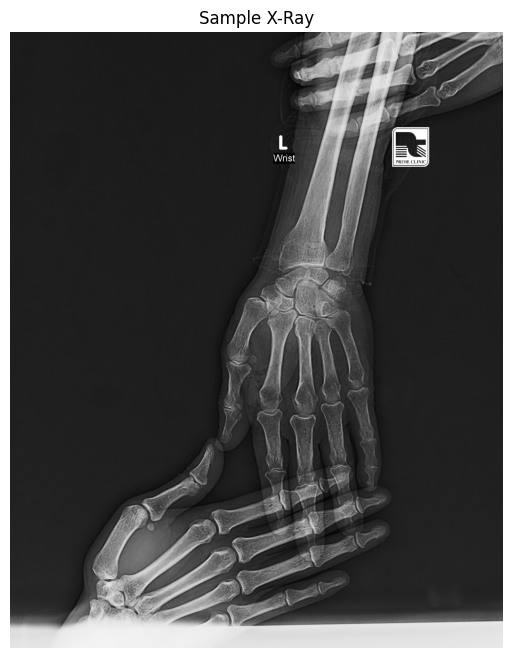

In [25]:
image_path_map = {
    os.path.basename(path): path
    for path in image_files
}

sample_image_info = coco_data["images"][0]

sample_image_id = sample_image_info["id"]
sample_image_name = sample_image_info["file_name"]
sample_image_path = image_path_map[sample_image_name]

sample_image = Image.open(sample_image_path).convert("L")

print(f"Image ID   : {sample_image_id}")
print(f"Image Name : {sample_image_name}")
print(f"Image Size : {sample_image.size}")

plt.figure(figsize=(8, 8))
plt.imshow(sample_image, cmap="gray")
plt.axis("off")
plt.title("Sample X-Ray")
plt.show()

**Visualize Bounding Box:**

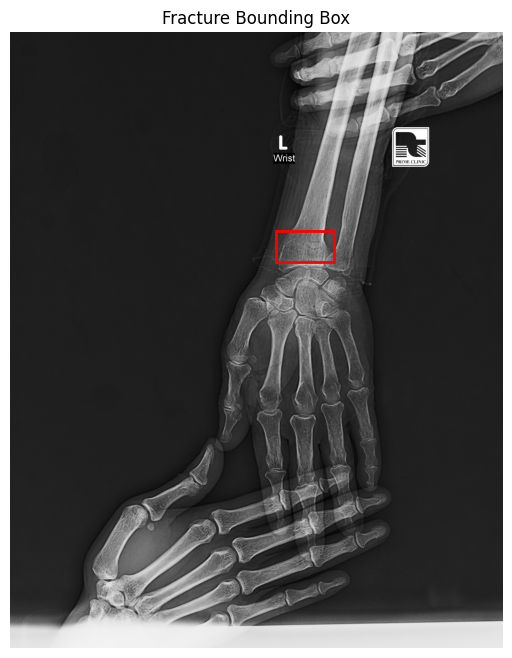

In [26]:
sample_annotations = image_annotations[sample_image_id]

plt.figure(figsize=(8, 8))
plt.imshow(sample_image, cmap="gray")

ax = plt.gca()

for annotation in sample_annotations:
  x, y, width, height = annotation["bbox"]

  rectangle = plt.Rectangle((x, y), width, height, linewidth=2, edgecolor="r", fill=False)
  ax.add_patch(rectangle)

plt.axis("off")
plt.title("Fracture Bounding Box")
plt.show()

**Generate Segmentation Mask:**

Mask Size: (2304, 2880)


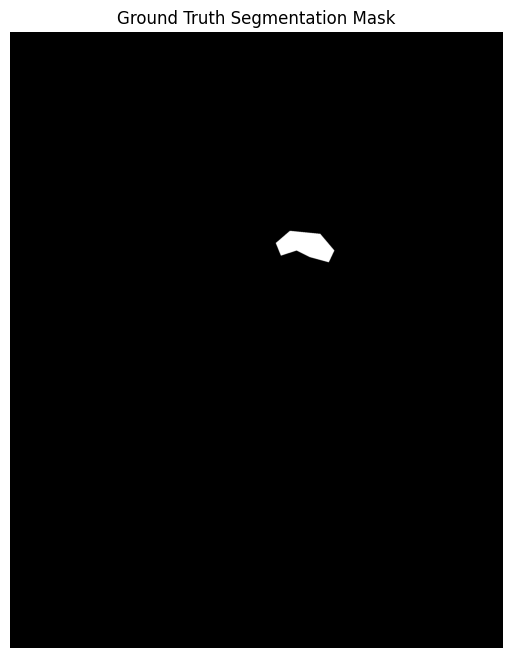

In [27]:
mask = Image.new("L", sample_image.size, 0)
draw = ImageDraw.Draw(mask)

for annotation in sample_annotations:
  segmentation = annotation.get("segmentation", [])

  for polygon in segmentation:
    points = [(polygon[i], polygon[i + 1]) for i in range(0, len(polygon), 2)]
    draw.polygon(points, fill=255)

print(f"Mask Size: {mask.size}")

plt.figure(figsize=(8, 8))
plt.imshow(mask, cmap="gray")
plt.axis("off")
plt.title("Ground Truth Segmentation Mask")
plt.show()

**Train Validation Split:**

In [28]:
annotated_images = coco_data["images"]

train_images, val_images = train_test_split(
    annotated_images, test_size=0.2, random_state=SEED
)

print(f"Total Images      : {len(annotated_images)}")
print(f"Training Images   : {len(train_images)}")
print(f"Validation Images : {len(val_images)}")

Total Images      : 717
Training Images   : 573
Validation Images : 144


**Create Segmentation Dataset:**

In [29]:
class FracAtlasSegmentationDataset(Dataset):

    def __init__(self, image_infos, image_path_map, coco_data, augment=False):
        self.image_infos = image_infos
        self.image_path_map = image_path_map
        self.augment = augment
        self.annotations = defaultdict(list)

        for annotation in coco_data["annotations"]:
            self.annotations[annotation["image_id"]].append(annotation)

    def __len__(self):
        return len(self.image_infos)

    def __getitem__(self, index):
        image_info = self.image_infos[index]
        image_id = image_info["id"]
        image_name = image_info["file_name"]
        image_file = self.image_path_map[image_name]
        image = Image.open(image_file).convert("L")
        mask = Image.new("L", image.size, 0)
        draw = ImageDraw.Draw(mask)

        for annotation in self.annotations[image_id]:
            for polygon in annotation.get("segmentation", []):
                points = [(polygon[i], polygon[i + 1])
                          for i in range(0, len(polygon), 2)]
                draw.polygon(points, fill=255)

        if self.augment:
            if random.random() < 0.5:
                image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
                mask = mask.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
            if random.random() < 0.35:
                angle = random.uniform(-8.0, 8.0)
                image = image.rotate(angle, resample=Image.Resampling.BILINEAR,
                                     fillcolor=0)
                mask = mask.rotate(angle, resample=Image.Resampling.NEAREST,
                                   fillcolor=0)

        image = image.resize((IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.BILINEAR)
        mask = mask.resize((IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.NEAREST)

        image = np.asarray(image, dtype=np.float32) / 255.0
        mask = np.asarray(mask, dtype=np.float32) / 255.0
        if self.augment:
            if random.random() < 0.35:
                contrast = random.uniform(0.85, 1.15)
                image = np.clip((image - 0.5) * contrast + 0.5, 0.0, 1.0)
            if random.random() < 0.25:
                image = np.clip(image + random.uniform(-0.05, 0.05), 0.0, 1.0)

        image = torch.from_numpy(image.copy()).unsqueeze(0)
        mask = torch.from_numpy((mask > 0.5).astype(np.float32)).unsqueeze(0)
        return image, mask

**Create DataLoaders:**

In [30]:
train_dataset = FracAtlasSegmentationDataset(
    train_images, image_path_map, coco_data, augment=True
)
val_dataset = FracAtlasSegmentationDataset(
    val_images, image_path_map, coco_data, augment=False
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

print(f"Training Samples   : {len(train_dataset)}")
print(f"Validation Samples : {len(val_dataset)}")

Training Samples   : 573
Validation Samples : 144


**Define Lightweight U-Net:**

In [31]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(1, 16)
        self.enc2 = DoubleConv(16, 32)
        self.enc3 = DoubleConv(32, 64)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(64, 128)
        self.dropout = nn.Dropout2d(0.15)
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec3 = DoubleConv(128, 64)
        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = DoubleConv(64, 32)
        self.up1 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec1 = DoubleConv(32, 16)
        self.output = nn.Conv2d(16, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.dropout(self.bottleneck(self.pool(e3)))
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.output(d1)

model = UNet().to(DEVICE)
print(model)

UNet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequen

**Define Weighted Loss And Optimizer:**

In [32]:
positive_pixels = 0
negative_pixels = 0

for _, mask in FracAtlasSegmentationDataset(
    train_images, image_path_map, coco_data, augment=False
):
    positive = (mask > 0.5).sum().item()
    total = mask.numel()
    positive_pixels += positive
    negative_pixels += total - positive

pos_weight_value = negative_pixels / max(positive_pixels, 1)
pos_weight_value = float(np.clip(pos_weight_value, 1.0, 30.0))
print(f"Positive Pixels : {positive_pixels:,}")
print(f"Negative Pixels : {negative_pixels:,}")
print(f"Clipped Positive Weight : {pos_weight_value:.2f}")

pos_weight = torch.tensor([pos_weight_value], device=DEVICE)
bce_loss = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def dice_loss(predictions, targets, smooth=1.0):
    probabilities = torch.sigmoid(predictions)
    probabilities = probabilities.flatten(1)
    targets = targets.flatten(1)
    intersection = (probabilities * targets).sum(dim=1)
    dice = (2 * intersection + smooth) / (
        probabilities.sum(dim=1) + targets.sum(dim=1) + smooth
    )
    return (1 - dice).mean()

def combined_loss(predictions, targets):
    return 0.5 * bce_loss(predictions, targets) + dice_loss(predictions, targets)

optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6
)
print("Weighted Loss, Optimizer And Scheduler Ready.")

Positive Pixels : 412,300
Negative Pixels : 84,079,988
Clipped Positive Weight : 30.00
Weighted Loss, Optimizer And Scheduler Ready.


**Train Model:**

In [39]:
model = UNet().to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6
)

train_losses, val_losses, val_dices, val_ious = [], [], [], []
best_dice = -1.0
best_state = None
patience_counter = 0

for epoch in range(NUM_EPOCHS):
    model.train()
    running_train_loss = 0.0
    for images, masks in train_loader:
        images, masks = images.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = combined_loss(outputs, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_train_loss += loss.item()

    train_loss = running_train_loss / max(len(train_loader), 1)
    model.eval()
    running_val_loss = 0.0
    dice_sum = iou_sum = 0.0
    sample_count = 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            logits = model(images)
            running_val_loss += combined_loss(logits, masks).item()
            predictions = (torch.sigmoid(logits) > 0.5).float()
            for pred, target in zip(predictions, masks):
                pred, target = pred.flatten(), target.flatten()
                intersection = (pred * target).sum()
                pred_area, target_area = pred.sum(), target.sum()
                if pred_area == 0 and target_area == 0:
                    dice, iou = 1.0, 1.0
                else:
                    dice = (2 * intersection + 1e-6) / (pred_area + target_area + 1e-6)
                    union = pred_area + target_area - intersection
                    iou = (intersection + 1e-6) / (union + 1e-6)
                dice_sum += dice.item()
                iou_sum += iou.item()
                sample_count += 1

    val_loss = running_val_loss / max(len(val_loader), 1)
    val_dice = dice_sum / max(sample_count, 1)
    val_iou = iou_sum / max(sample_count, 1)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_dices.append(val_dice)
    val_ious.append(val_iou)
    scheduler.step(val_dice)

    if val_dice > best_dice:
        best_dice = val_dice
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    current_lr = optimizer.param_groups[0]["lr"]
    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Dice: {val_dice:.4f} | IoU: {val_iou:.4f} | LR: {current_lr:.2e}"
    )
    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print("Early stopping: validation Dice did not improve.")
        break

if best_state is not None:
    model.load_state_dict(best_state)
model = model.to(DEVICE)
print(f"Best Validation Dice: {best_dice:.4f}")

Epoch [1/20] | Train Loss: 1.3080 | Val Loss: 1.3521 | Dice: 0.0509 | IoU: 0.0266 | LR: 3.00e-04
Epoch [2/20] | Train Loss: 1.2589 | Val Loss: 1.2425 | Dice: 0.1267 | IoU: 0.0736 | LR: 3.00e-04
Epoch [3/20] | Train Loss: 1.2331 | Val Loss: 1.2196 | Dice: 0.1156 | IoU: 0.0649 | LR: 3.00e-04
Epoch [4/20] | Train Loss: 1.2103 | Val Loss: 1.1968 | Dice: 0.1072 | IoU: 0.0588 | LR: 3.00e-04
Epoch [5/20] | Train Loss: 1.1894 | Val Loss: 1.1832 | Dice: 0.0959 | IoU: 0.0522 | LR: 3.00e-04
Epoch [6/20] | Train Loss: 1.1724 | Val Loss: 1.1580 | Dice: 0.2114 | IoU: 0.1312 | LR: 3.00e-04
Epoch [7/20] | Train Loss: 1.1504 | Val Loss: 1.1472 | Dice: 0.1387 | IoU: 0.0792 | LR: 3.00e-04
Epoch [8/20] | Train Loss: 1.1338 | Val Loss: 1.1334 | Dice: 0.1130 | IoU: 0.0632 | LR: 3.00e-04
Epoch [9/20] | Train Loss: 1.1158 | Val Loss: 1.1217 | Dice: 0.2391 | IoU: 0.1624 | LR: 3.00e-04
Epoch [10/20] | Train Loss: 1.1005 | Val Loss: 1.0855 | Dice: 0.2476 | IoU: 0.1547 | LR: 3.00e-04
Epoch [11/20] | Train Loss: 1

**Evaluate Dice And IoU:**

In [41]:
model.eval()

all_probabilities = []
all_targets = []

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        probabilities = torch.sigmoid(model(images))

        all_probabilities.append(probabilities.cpu())
        all_targets.append(masks.cpu())

all_probabilities = torch.cat(all_probabilities, dim=0)
all_targets = torch.cat(all_targets, dim=0)

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    predictions = (all_probabilities > threshold).float()

    dice_scores = []
    iou_scores = []
    precision_scores = []
    recall_scores = []

    for prediction, target in zip(predictions, all_targets):
        prediction = prediction.flatten()
        target = target.flatten()

        true_positive = (prediction * target).sum()
        false_positive = (prediction * (1 - target)).sum()
        false_negative = ((1 - prediction) * target).sum()

        prediction_area = prediction.sum()
        target_area = target.sum()

        if prediction_area == 0 and target_area == 0:
            dice = 1.0
            iou = 1.0
        else:
            dice = (
                (2 * true_positive + 1e-6) /
                (prediction_area + target_area + 1e-6)
            )

            union = prediction_area + target_area - true_positive

            iou = (
                (true_positive + 1e-6) /
                (union + 1e-6)
            )

        precision = (
            (true_positive + 1e-6) /
            (true_positive + false_positive + 1e-6)
        )

        recall = (
            (true_positive + 1e-6) /
            (true_positive + false_negative + 1e-6)
        )

        dice_scores.append(dice.item())
        iou_scores.append(iou.item())
        precision_scores.append(precision.item())
        recall_scores.append(recall.item())

    threshold_results.append({
        "threshold": float(threshold),
        "dice": float(np.mean(dice_scores)),
        "iou": float(np.mean(iou_scores)),
        "precision": float(np.mean(precision_scores)),
        "recall": float(np.mean(recall_scores)),
    })

best_result = max(threshold_results, key=lambda item: item["dice"])

THRESHOLD = best_result["threshold"]
mean_dice = best_result["dice"]
mean_iou = best_result["iou"]
mean_precision = best_result["precision"]
mean_recall = best_result["recall"]

best_predictions = (all_probabilities > THRESHOLD).float()
mean_foreground = best_predictions.mean().item()

print("=" * 60)
print("Optimized Validation Results")
print("=" * 60)
print(f"Best Threshold       : {THRESHOLD:.2f}")
print(f"Validation Dice      : {mean_dice:.4f}")
print(f"Validation IoU       : {mean_iou:.4f}")
print(f"Validation Precision : {mean_precision:.4f}")
print(f"Validation Recall    : {mean_recall:.4f}")
print(f"Predicted Foreground : {mean_foreground * 100:.2f}%")
print("=" * 60)

Optimized Validation Results
Best Threshold       : 0.75
Validation Dice      : 0.3598
Validation IoU       : 0.2572
Validation Precision : 0.3969
Validation Recall    : 0.4942
Predicted Foreground : 0.68%


**Plot Training History:**

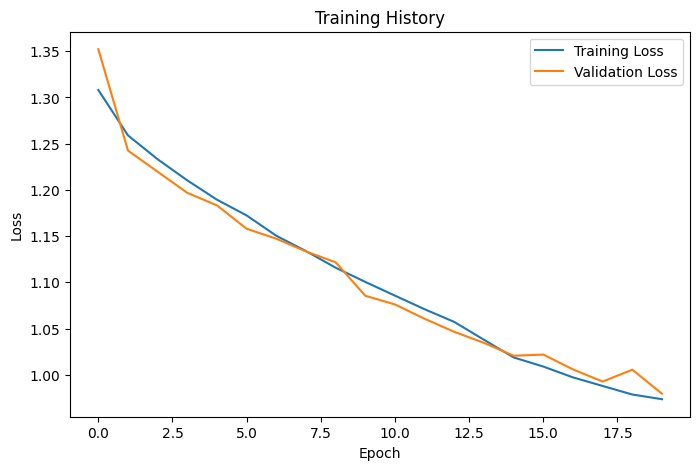

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training History")
plt.legend()

plt.show()

**Save Model:**

In [43]:
model_path = "/content/savalanai_fracatlas_unet_best.pth"
torch.save({
    "model_state_dict": model.state_dict(),
    "image_size": IMAGE_SIZE,
    "threshold": THRESHOLD,
    "best_val_dice": best_dice,
}, model_path)
print("Best model saved successfully.")
print(f"Model Path: {model_path}")

Best model saved successfully.
Model Path: /content/savalanai_fracatlas_unet_best.pth


**Download Model:**

In [48]:
files.download(model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Load Saved Model:**

In [44]:
loaded_model = UNet().to(DEVICE)
checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
if "model_state_dict" in checkpoint:
    loaded_model.load_state_dict(checkpoint["model_state_dict"])
else:
    loaded_model.load_state_dict(checkpoint)
loaded_model.eval()
print("Model Loaded Successfully.")

Model Loaded Successfully.


**Visualize Prediction:**

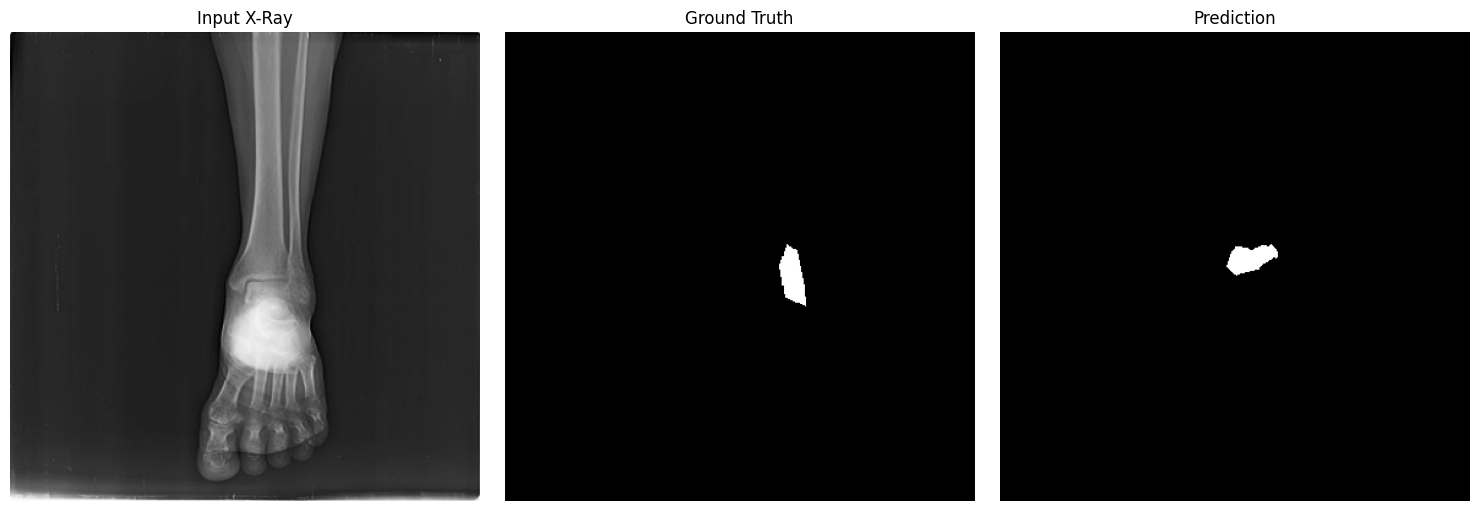

In [45]:
sample_image_tensor, sample_mask_tensor = val_dataset[0]

with torch.no_grad():
    prediction = loaded_model(
        sample_image_tensor.unsqueeze(0).to(DEVICE)
    )

    prediction = torch.sigmoid(prediction)

prediction = prediction.squeeze().cpu().numpy()
sample_image_np = sample_image_tensor.squeeze().numpy()
sample_mask_np = sample_mask_tensor.squeeze().numpy()

prediction = (prediction > 0.5).astype(np.float32)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(sample_image_np, cmap="gray")
plt.title("Input X-Ray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sample_mask_np, cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(prediction, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

**Final Results:**

In [46]:
print("=" * 50)
print("SavalanAI - FracAtlas Segmentation")
print("=" * 50)
print(f"Dataset Images       : {len(annotated_images)}")
print(f"Training Images      : {len(train_images)}")
print(f"Validation Images    : {len(val_images)}")
print(f"Image Size           : {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Batch Size           : {BATCH_SIZE}")
print(f"Epochs               : {NUM_EPOCHS}")
print(f"Learning Rate        : {LEARNING_RATE}")
print(f"Device               : {DEVICE}")
print(f"Best Validation Dice : {best_dice:.4f}")
print(f"Validation Dice      : {mean_dice:.4f}")
print(f"Validation IoU       : {mean_iou:.4f}")
print(f"Model Path           : {model_path}")
print("=" * 50)
print("Training Completed Successfully.")

SavalanAI - FracAtlas Segmentation
Dataset Images       : 717
Training Images      : 573
Validation Images    : 144
Image Size           : 384x384
Batch Size           : 8
Epochs               : 20
Learning Rate        : 0.0003
Device               : cuda
Best Validation Dice : 0.3217
Validation Dice      : 0.3598
Validation IoU       : 0.2572
Model Path           : /content/savalanai_fracatlas_unet_best.pth
Training Completed Successfully.
